In [12]:
import cv2
import numpy as np
import torch
from PIL import Image
import requests
from transformers import SamModel, SamProcessor
from time import time
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [15, 10]

In [13]:
device = torch.device('cpu')
model = SamModel.from_pretrained("facebook/sam-vit-huge").to(device)
processor = SamProcessor.from_pretrained("facebook/sam-vit-huge")

In [53]:
img_url = "https://huggingface.co/ybelkada/segment-anything/resolve/main/assets/car.png"
raw_image = Image.open(requests.get(img_url, stream=True).raw).convert("RGB")
#input_points = [[[450,600]]]
input_points = [[[800,1100]]] #wheel

inputs = processor(raw_image, input_points=input_points, return_tensors="pt").to(device)
with torch.no_grad():
    outputs = model(**inputs)

masks = processor.image_processor.post_process_masks(
    outputs.pred_masks.cpu(), inputs["original_sizes"].cpu(), inputs["reshaped_input_sizes"].cpu()
)
scores = outputs.iou_scores

In [54]:
masks[0].shape, raw_image.size, len(masks)

(torch.Size([1, 3, 1764, 2646]), (2646, 1764), 1)

In [57]:
masks_np = [masks[0].squeeze()[idx, ...].numpy() for idx in range(3)]
masks_np.reverse()
image = np.array(raw_image)

(<Axes: >, <matplotlib.image.AxesImage at 0x16782b890>)

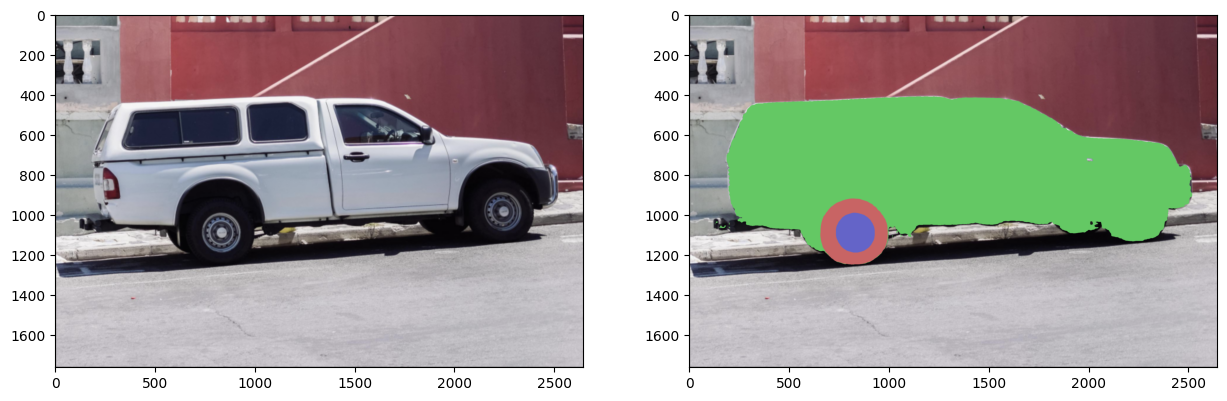

In [59]:
plt.subplot(121), plt.imshow(image)

image_out = image.copy().astype(np.float32)
colors =[(100, 200, 100), (200, 100, 100), (100, 100, 200)]
for idx, mask in enumerate(masks_np):
    image_out[..., :][mask] = colors[idx]

plt.subplot(122), plt.imshow(image_out.astype(np.uint8))